In [3]:
import kagglehub

# Download latest version
#path = kagglehub.dataset_download("ashery/chexpert")

#print("Path to dataset files:", path)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from PIL import Image
import os
import random
import seaborn as sns

In [5]:
base_path = "../data"  

train_df = pd.read_csv(f"{base_path}/train.csv")
valid_df = pd.read_csv(f"{base_path}/valid.csv")

train_df["full_path"] = train_df["Path"].str.replace("CheXpert-v1.0-small/", f"{base_path}/", regex=False)
valid_df["full_path"] = valid_df["Path"].str.replace("CheXpert-v1.0-small/", f"{base_path}/", regex=False)

train_df.head()

,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,full_path
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0,../data/train/patient00001/study1/view1_fronta...
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN,../data/train/patient00002/study2/view1_fronta...
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,../data/train/patient00002/study1/view1_fronta...
3,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,../data/train/patient00002/study1/view2_latera...
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,../data/train/patient00003/study1/view1_fronta...


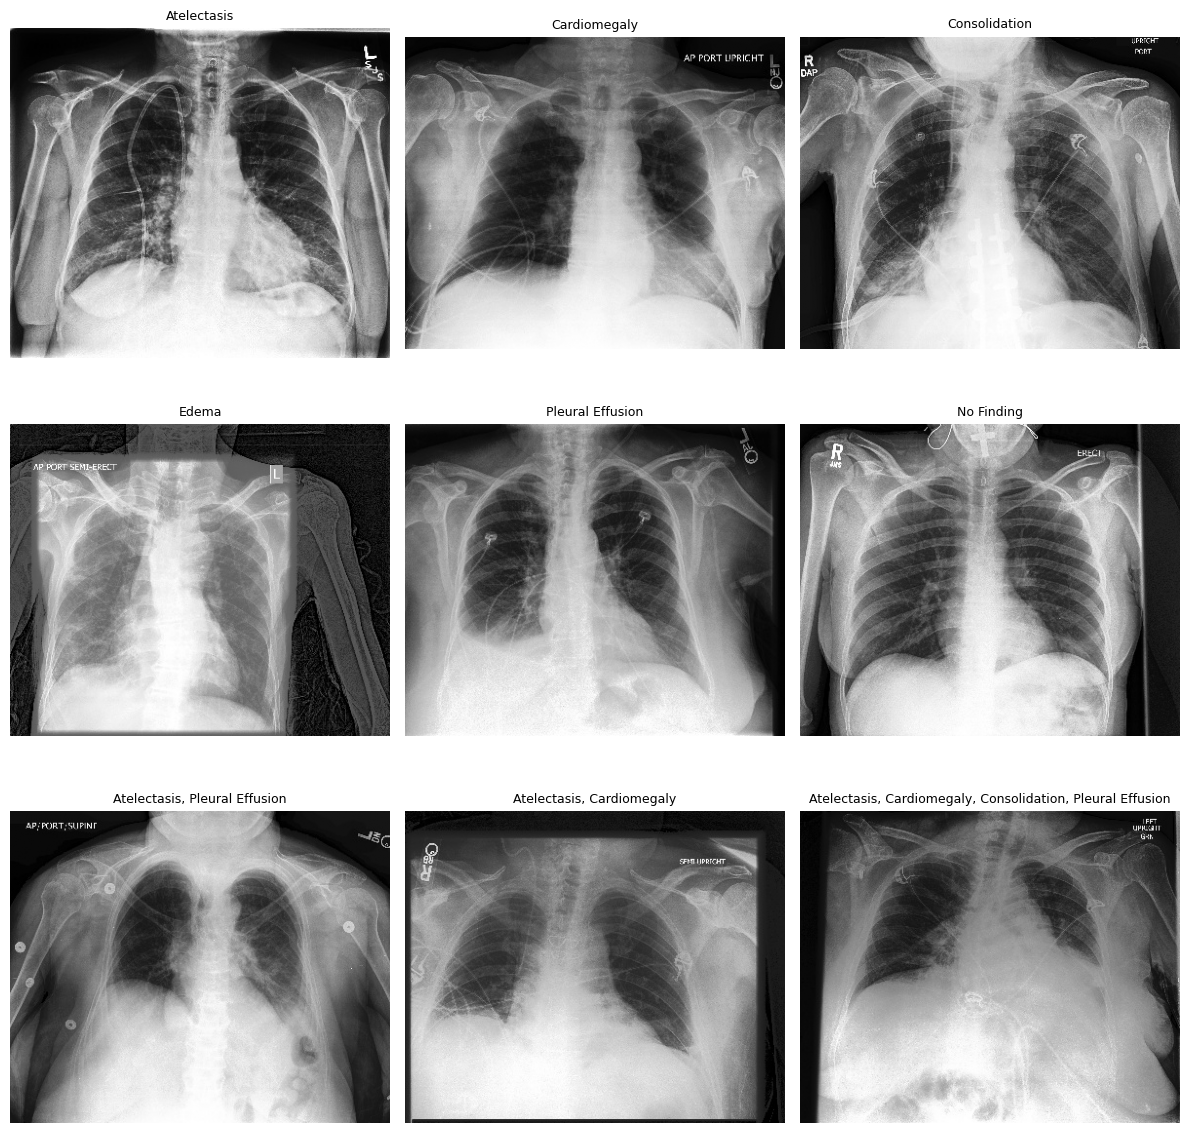

In [ ]:

class_names = ["Atelectasis", "Cardiomegaly", "Consolidation", "Edema", "Pleural Effusion"]

plot_df = valid_df.copy()
if "Frontal/Lateral" in plot_df.columns:
    plot_df = plot_df[plot_df["Frontal/Lateral"] == "Frontal"].copy()

plot_df["n_positive"] = plot_df[class_names].eq(1).sum(axis=1)

representatives = []

for disease in class_names:
    subset = plot_df[(plot_df[disease] == 1) & (plot_df["n_positive"] == 1)]
    if len(subset) > 0:
        representatives.append(subset.iloc[0])

no_finding = plot_df[plot_df["No Finding"] == 1]
if len(no_finding) > 0:
    representatives.append(no_finding.iloc[0])

multi_label = plot_df[plot_df["n_positive"] >= 2]
for _, row in multi_label.iterrows():
    if len(representatives) >= 9:
        break
    representatives.append(row)

used_paths = {row["full_path"] for row in representatives if "full_path" in row}
for _, row in plot_df.iterrows():
    if len(representatives) >= 9:
        break
    if row["full_path"] not in used_paths:
        representatives.append(row)
        used_paths.add(row["full_path"])

representatives = representatives[:9]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for ax, row in zip(axes, representatives):
    img = Image.open(row["full_path"]).convert("L")
    ax.imshow(img, cmap="gray")

    labels = [c for c in class_names if row[c] == 1]
    if row["No Finding"] == 1:
        title = "No Finding"
    elif labels:
        title = ", ".join(labels)
    else:
        title = "Other / unclear"

    ax.set_title(title, fontsize=9)
    ax.axis("off")

for ax in axes[len(representatives):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
pd.set_option("display.max_columns", None)

class_names = [
    "No Finding",
    "Enlarged Cardiomediastinum",
    "Cardiomegaly",
    "Lung Opacity",
    "Lung Lesion",
    "Edema",
    "Consolidation",
    "Pneumonia",
    "Atelectasis",
    "Pneumothorax",
    "Pleural Effusion",
    "Pleural Other",
    "Fracture",
    "Support Devices"
]

In [8]:
summary_df = pd.DataFrame({
    "positive": train_df[class_names].eq(1).sum(),
    "uncertain": train_df[class_names].eq(-1).sum(),
    "negative": train_df[class_names].eq(0).sum(),
    "missing": train_df[class_names].isna().sum()
})

summary_df["total_labeled"] = (
    summary_df["positive"] + summary_df["uncertain"] + summary_df["negative"]
)

summary_df["positive_pct"] = (summary_df["positive"] / summary_df["total_labeled"] * 100).round(2)
summary_df["uncertain_pct"] = (summary_df["uncertain"] / summary_df["total_labeled"] * 100).round(2)
summary_df["negative_pct"] = (summary_df["negative"] / summary_df["total_labeled"] * 100).round(2)

summary_df = summary_df.sort_values("positive", ascending=False)
display(summary_df)

,positive,uncertain,negative,missing,total_labeled,positive_pct,uncertain_pct,negative_pct
Support Devices,116001,1079,6137,100197,123217,94.14,0.88,4.98
Lung Opacity,105581,5598,6599,105636,117778,89.64,4.75,5.60
Pleural Effusion,86187,11628,35396,90203,133211,64.70,8.73,26.57
Edema,52246,12984,20726,137458,85956,60.78,15.11,24.11
Atelectasis,33376,33739,1328,154971,68443,48.76,49.30,1.94
Cardiomegaly,27000,8087,11116,177211,46203,58.44,17.50,24.06
No Finding,22381,0,0,201033,22381,100.00,0.00,0.00
Pneumothorax,19448,3145,56341,144480,78934,24.64,3.98,71.38
Consolidation,14783,27742,28097,152792,70622,20.93,39.28,39.79
Enlarged Cardiomediastinum,10798,12403,21638,178575,44839,24.08,27.66,48.26


In [9]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titleweight"] = "bold"

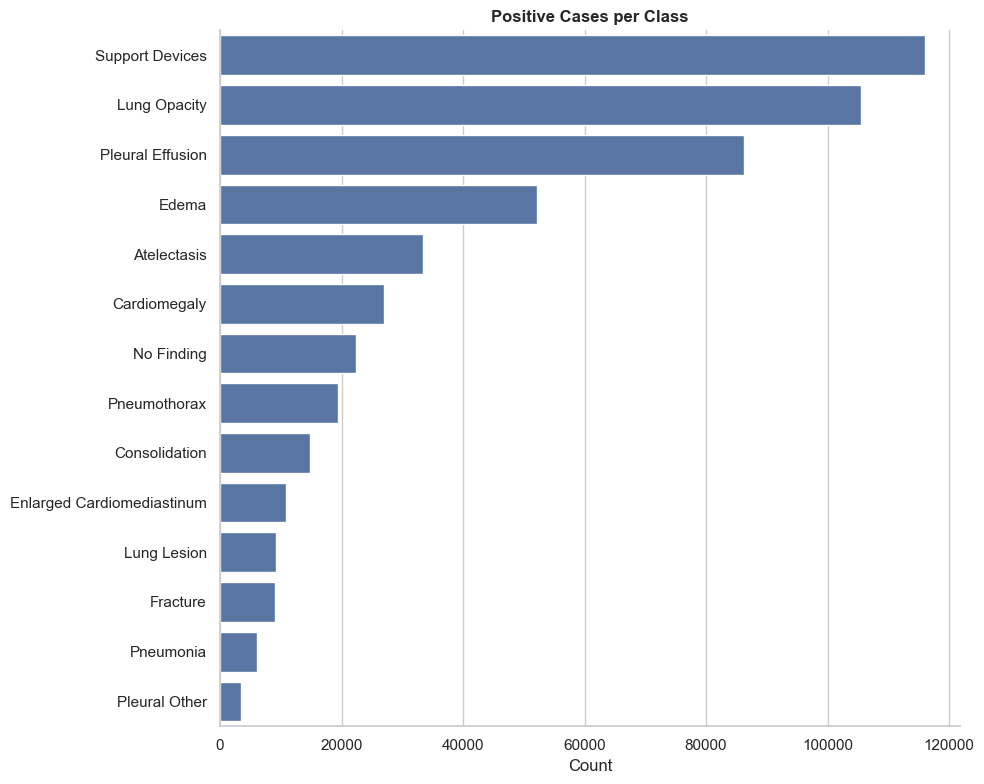

In [10]:
plot_df = summary_df.reset_index().rename(columns={"index": "Class"})
plot_df = plot_df.sort_values("positive", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=plot_df, x="positive", y="Class")
plt.title("Positive Cases per Class")
plt.xlabel("Count")
plt.ylabel("")
plt.tight_layout()
plt.show()

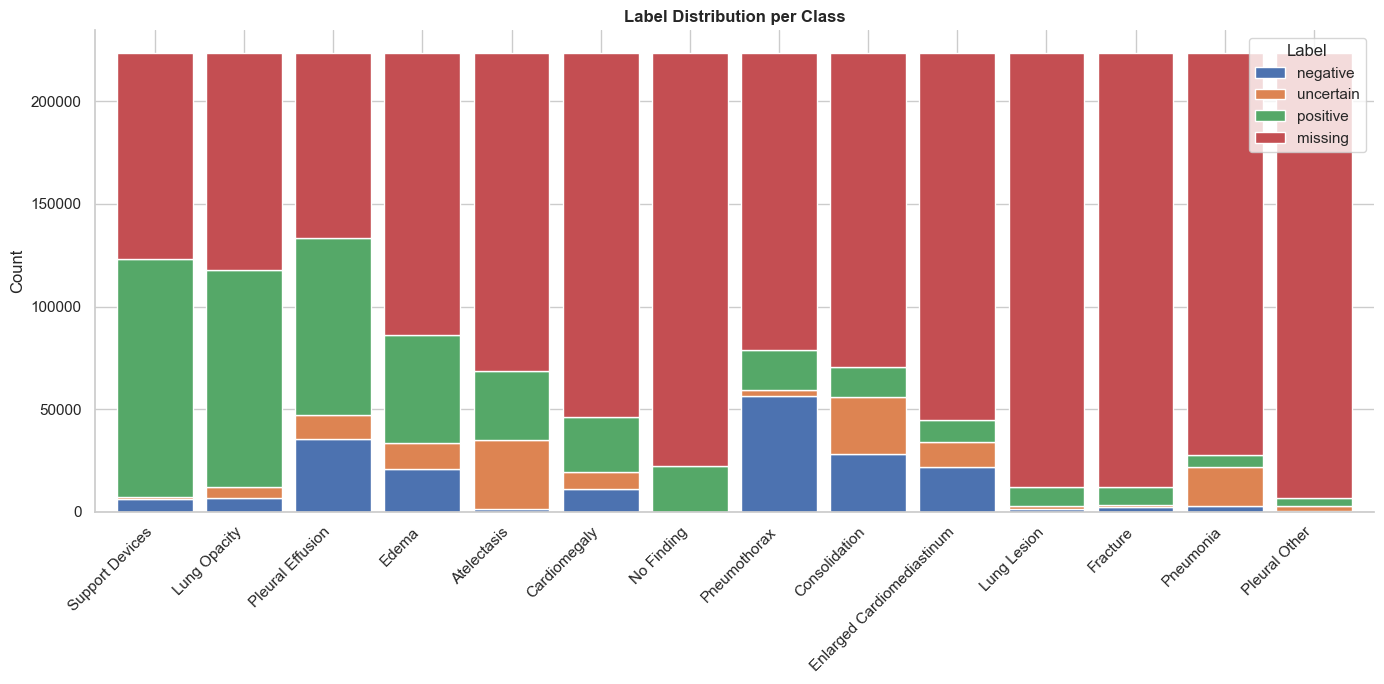

In [11]:
stacked_df = summary_df.sort_values("positive", ascending=False)

stacked_df[["negative", "uncertain", "positive", "missing"]].plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7),
    width=0.85
)

plt.title("Label Distribution per Class")
plt.xlabel("")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Label")
plt.tight_layout()
plt.show()

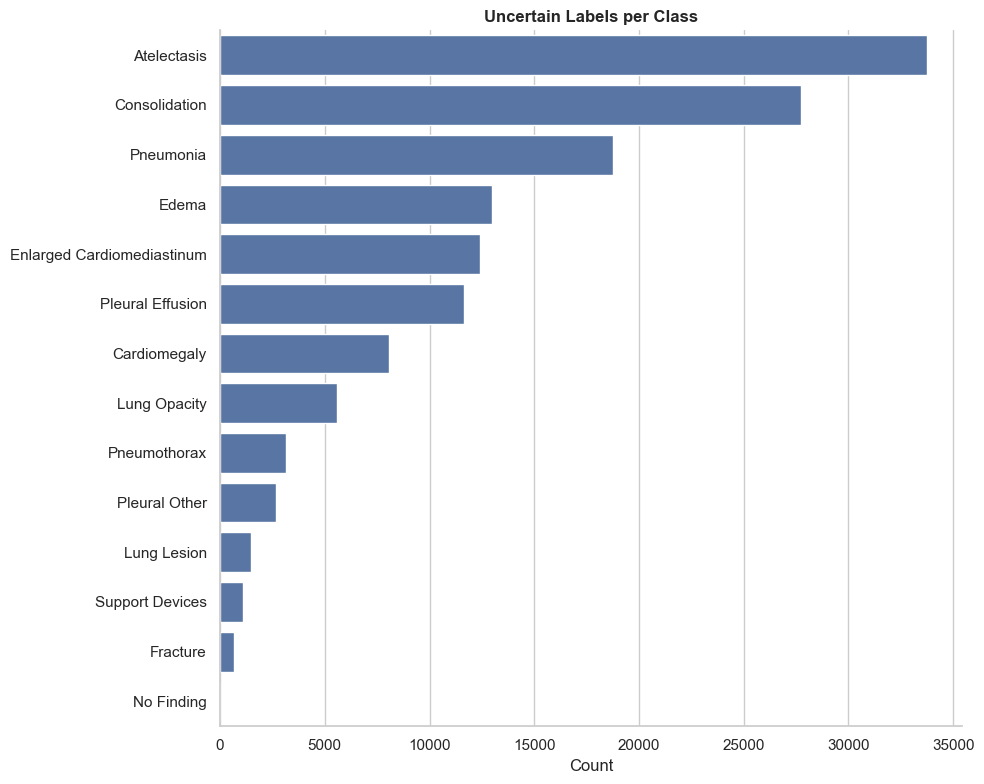

In [12]:
unc_df = summary_df.reset_index().rename(columns={"index": "Class"})
unc_df = unc_df.sort_values("uncertain", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=unc_df, x="uncertain", y="Class")
plt.title("Uncertain Labels per Class")
plt.xlabel("Count")
plt.ylabel("")
plt.tight_layout()
plt.show()

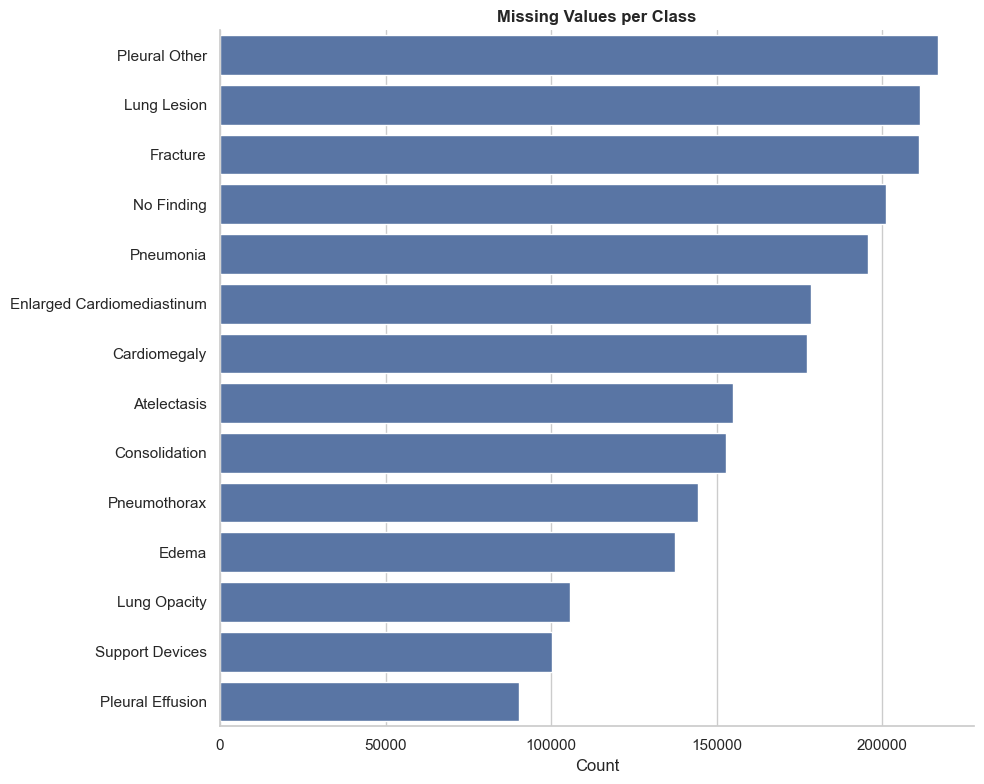

In [13]:
miss_df = summary_df.reset_index().rename(columns={"index": "Class"})
miss_df = miss_df.sort_values("missing", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=miss_df, x="missing", y="Class")
plt.title("Missing Values per Class")
plt.xlabel("Count")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [15]:
count_df = (
    train_df["n_positive_labels"]
    .value_counts()
    .sort_index()
    .rename_axis("n_labels")
    .reset_index(name="count")
)

plt.figure(figsize=(8, 5))
sns.barplot(data=count_df, x="n_labels", y="count")
plt.title("Number of Positive Labels per Image")
plt.xlabel("Number of positive labels")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

KeyError: 'n_positive_labels'

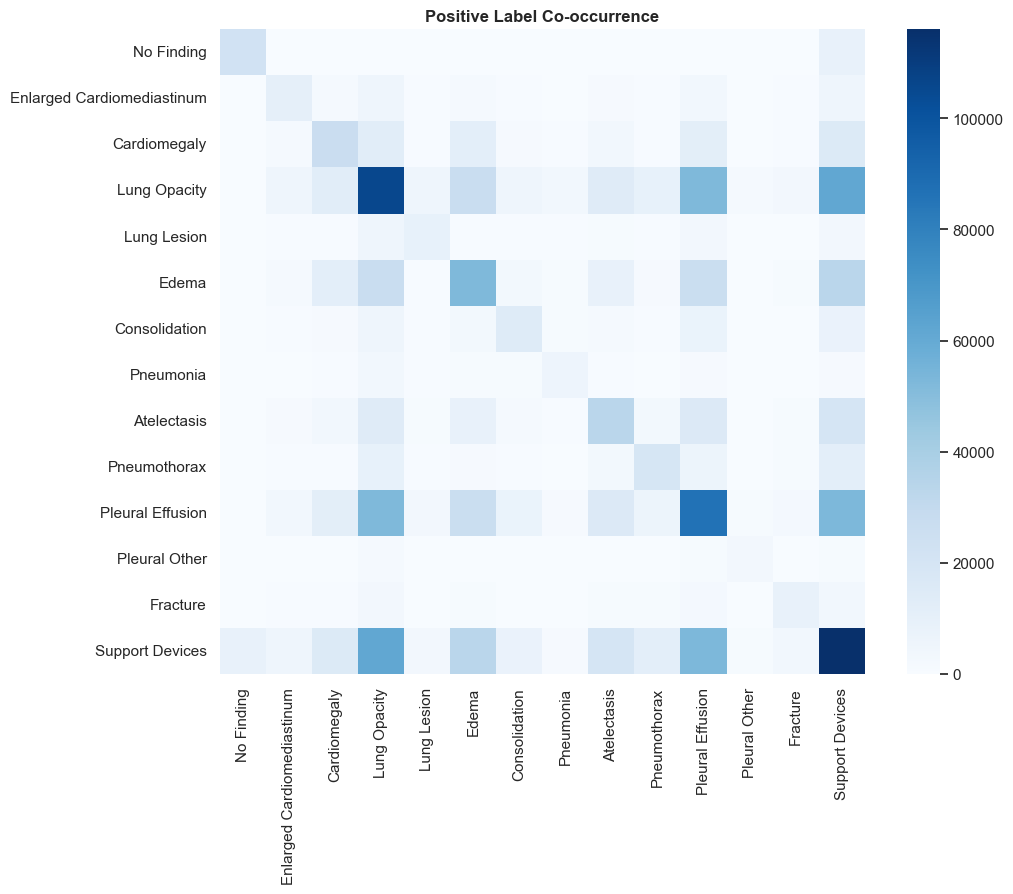

In [ ]:
positive_df = train_df[class_names].eq(1).astype(int)
co_occurrence = positive_df.T.dot(positive_df)

plt.figure(figsize=(11, 9))
sns.heatmap(co_occurrence, cmap="Blues", square=True)
plt.title("Positive Label Co-occurrence")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [ ]:
bins = range(0, 101, 10)

age_counts = (
    pd.cut(train_df["Age"], bins=bins, right=False)
    .value_counts()
    .sort_index()
    .reset_index()
)
age_counts.columns = ["Age group", "Count"]

plt.figure(figsize=(10, 5))
sns.barplot(data=age_counts, x="Age group", y="Count")
plt.title("Age Distribution")
plt.xlabel("Age group")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

NameError: name 'pd' is not defined

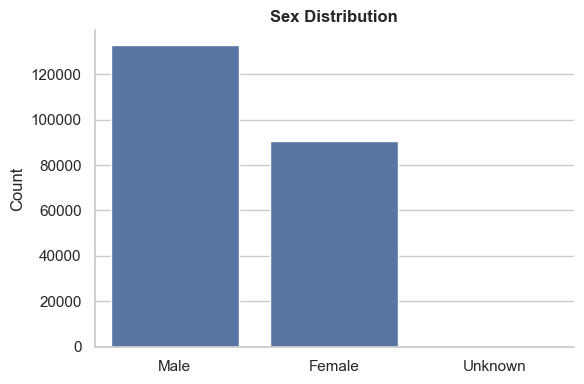

In [ ]:
sex_df = train_df["Sex"].value_counts(dropna=False).rename_axis("Sex").reset_index(name="Count")

plt.figure(figsize=(6, 4))
sns.barplot(data=sex_df, x="Sex", y="Count")
plt.title("Sex Distribution")
plt.xlabel("")
plt.tight_layout()
plt.show()

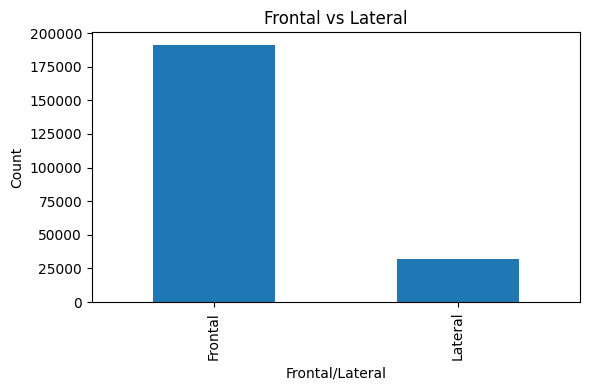

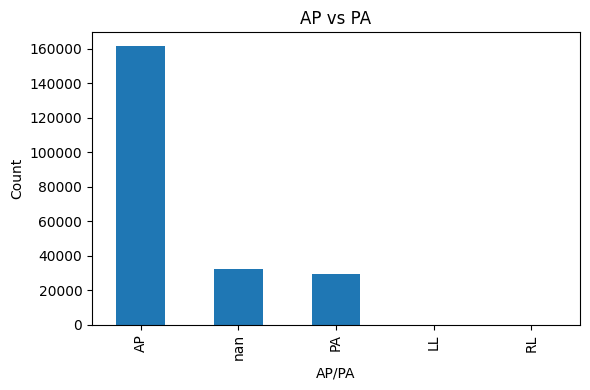

In [ ]:
plt.figure(figsize=(6, 4))
train_df["Frontal/Lateral"].value_counts(dropna=False).plot(kind="bar")
plt.title("Frontal vs Lateral")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
train_df["AP/PA"].value_counts(dropna=False).plot(kind="bar")
plt.title("AP vs PA")
plt.ylabel("Count")
plt.tight_layout()
plt.show()